# create correlated variables

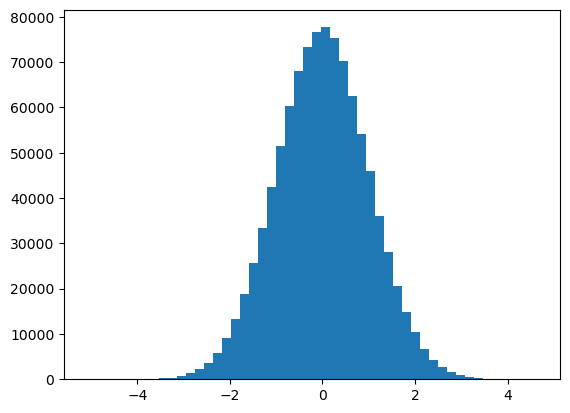

In [13]:
from numpy.random import normal
import matplotlib.pyplot as plt

plt.hist(normal(size=1000000),50)
plt.show()

correlation = -0.49914


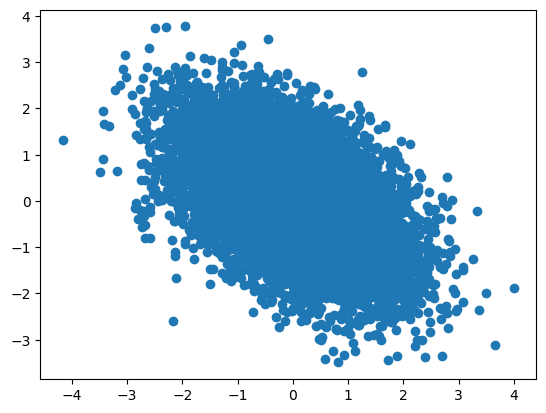

In [14]:
import numpy as np
from numpy.random import normal
import matplotlib.pyplot as plt

n = 10000

rho = -.5
z = normal(size=(2,n))
e0 = z[0]
e1 = rho * z[0] + np.sqrt(1 - pow(rho,2)) * z[1]

print(f"correlation = {np.corrcoef(e0,e1)[1,0]:0.5f}")
plt.plot(e0, e1, 'o')
plt.show()

# simulating future returns
## Cholesky decomposition of correlation matrix

In [3]:
import pandas as pd
import yfinance as yf
from math import log

companies, tickers = ['Meta','Amazon','Apple','Netflix','Google'],['META','AMZN','AAPL','NFLX','GOOG']

# DJ30 = pd.read_excel('DowJones30.xlsx',header=None)
# tickers, companies = list(DJ30.iloc[:-1,0].values), list(DJ30.iloc[:-1,1].values) # exclude DOW 

tickers_df = yf.download(tickers, 
                      start='2017-01-01', 
                      end='2024-02-02', 
                      progress=False, auto_adjust=True)
returns = tickers_df['Close'].map(log).diff()[1:]

corr = returns.corr()
corr

Ticker,AAPL,AMZN,GOOG,META,NFLX
Ticker,,,,,
AAPL,1.000000,0.620158,0.667103,0.564372,0.460479
AMZN,0.620158,1.000000,0.676512,0.604120,0.563403
GOOG,0.667103,0.676512,1.000000,0.656390,0.482799
META,0.564372,0.604120,0.656390,1.000000,0.489839
NFLX,0.460479,0.563403,0.482799,0.489839,1.000000


# simulate returns with the same correlation structure

## Cholesky decomposition:
$\begin{equation*}
C =  \begin{bmatrix}
1 & 0 & 0 & 0 & ...\\
c_{21} & c_{22} & 0  & 0 & ...\\
c_{31} & c_{32} & c_{33} & 0 & ...\\
c_{41} & c_{42} & c_{43} & c_{44} & ... \\
... & ... & ... & ... & ...\\
\end{bmatrix}
\end{equation*}$

### so that $C * C^T = $ original correlation matrix

In [4]:
from numpy.linalg import cholesky

cholesky_decomp = cholesky(corr)   ###################  create Cholesky matrix
print("cholesky decomposition of correlation matrix")
pd.DataFrame(cholesky_decomp)

cholesky decomposition of correlation matrix


,0,1,2,3,4
0,1.000000,0.000000,0.000000,0.000000,0.000000
1,0.620158,0.784477,0.000000,0.000000,0.000000
2,0.667103,0.335004,0.665392,0.000000,0.000000
3,0.564372,0.323935,0.257556,0.714293,0.000000
4,0.460479,0.354164,0.085613,0.130452,0.798861


In [5]:
row_number = 3

display(cholesky_decomp[row_number,:])

row_squared = cholesky_decomp[row_number,:] * cholesky_decomp[row_number,:]
display(row_squared)
print(sum(row_squared))

array([0.56437229, 0.32393545, 0.25755618, 0.71429305, 0.        ])

array([0.31851608, 0.10493417, 0.06633518, 0.51021456, 0.        ])

1.0


In [6]:
print("historal correlation matrix")
display(pd.DataFrame(corr))

print("CC^T matrix where C = Cholesky matrix")
display(pd.DataFrame(cholesky_decomp.dot(cholesky_decomp.T)))

historal correlation matrix


Ticker,AAPL,AMZN,GOOG,META,NFLX
Ticker,,,,,
AAPL,1.000000,0.620158,0.667103,0.564372,0.460479
AMZN,0.620158,1.000000,0.676512,0.604120,0.563403
GOOG,0.667103,0.676512,1.000000,0.656390,0.482799
META,0.564372,0.604120,0.656390,1.000000,0.489839
NFLX,0.460479,0.563403,0.482799,0.489839,1.000000


CC^T matrix where C = Cholesky matrix


,0,1,2,3,4
0,1.000000,0.620158,0.667103,0.564372,0.460479
1,0.620158,1.000000,0.676512,0.604120,0.563403
2,0.667103,0.676512,1.000000,0.656390,0.482799
3,0.564372,0.604120,0.656390,1.000000,0.489839
4,0.460479,0.563403,0.482799,0.489839,1.000000


## Use the Cholesky matrix to simulated returns with a target correlation

### $C^T * C = \Sigma$ = n x n correlation
### m x n matrix of uncorrelated variables with column mean zero = $U$  : $U^T * U = I$ 
### create m x n matrix $S = U * C = (C^T * U^T)^T$
### so
### $S^T * S = (C^T * U^T) * (U * C) = C^T * (U^T * U) * C = C^T * C = \Sigma$

In [7]:
uncorrelated_set = normal(size=(5, n))
print("uncorrelated simulated time series : shape = "+ str(pd.DataFrame(uncorrelated_set).shape))
pd.DataFrame(uncorrelated_set).T.corr()

uncorrelated simulated time series : shape = (5, 10000)


,0,1,2,3,4
0,1.000000,-0.006643,-0.007054,0.001479,0.010223
1,-0.006643,1.000000,-0.012378,0.022161,0.005366
2,-0.007054,-0.012378,1.000000,-0.018183,0.001327
3,0.001479,0.022161,-0.018183,1.000000,0.014424
4,0.010223,0.005366,0.001327,0.014424,1.000000


# convert uncorrelated random variables into a correlated variables



In [8]:
simulations = cholesky_decomp.dot(uncorrelated_set).T   ##############   create correlated variables
sim_returns = pd.DataFrame(simulations,columns=returns.columns)
print("simmulated correlated variables : shape = " + str(sim_returns.shape))

simmulated correlated variables : shape = (10000, 5)


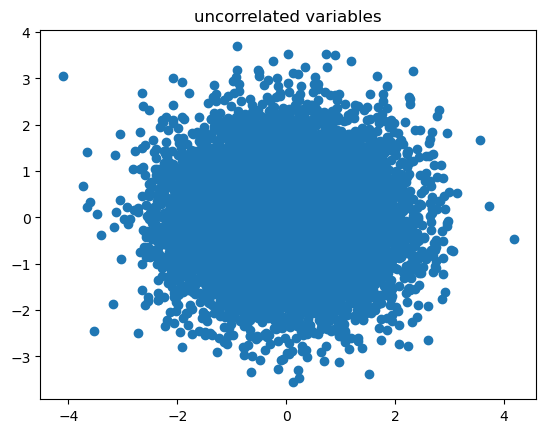

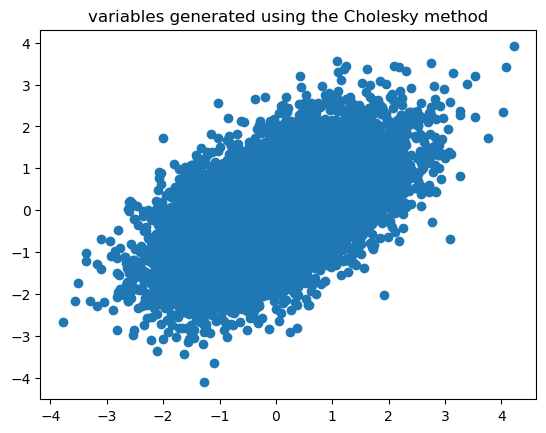

In [9]:
plt.plot(uncorrelated_set[0],uncorrelated_set[1],'o')
plt.title("uncorrelated variables")
plt.show()
plt.plot(simulations.T[4],simulations.T[1],'o')
plt.title("variables generated using the Cholesky method")
plt.show()

In [10]:
print("correlation matrix from simulated data")
simulation_corr = sim_returns.corr()
simulation_corr

correlation matrix from simulated data


Ticker,AAPL,AMZN,GOOG,META,NFLX
Ticker,,,,,
AAPL,1.000000,0.615843,0.664576,0.562898,0.467084
AMZN,0.615843,1.000000,0.669164,0.613189,0.573090
GOOG,0.664576,0.669164,1.000000,0.650415,0.486752
META,0.562898,0.613189,0.650415,1.000000,0.507234
NFLX,0.467084,0.573090,0.486752,0.507234,1.000000


In [11]:
print("correlation matrix for historical returns")
historical_corr = pd.DataFrame(corr)
historical_corr

correlation matrix for historical returns


Ticker,AAPL,AMZN,GOOG,META,NFLX
Ticker,,,,,
AAPL,1.000000,0.620158,0.667103,0.564372,0.460479
AMZN,0.620158,1.000000,0.676512,0.604120,0.563403
GOOG,0.667103,0.676512,1.000000,0.656390,0.482799
META,0.564372,0.604120,0.656390,1.000000,0.489839
NFLX,0.460479,0.563403,0.482799,0.489839,1.000000


In [12]:
print("deviation of correlation matrices for historical data versus simulated data")
historical_corr - simulation_corr

deviation of correlation matrices for historical data versus simulated data


Ticker,AAPL,AMZN,GOOG,META,NFLX
Ticker,,,,,
AAPL,0.000000,0.004314,0.002527,0.001474,-0.006605
AMZN,0.004314,0.000000,0.007349,-0.009069,-0.009687
GOOG,0.002527,0.007349,0.000000,0.005975,-0.003953
META,0.001474,-0.009069,0.005975,0.000000,-0.017395
NFLX,-0.006605,-0.009687,-0.003953,-0.017395,0.000000
